# 04 — Dataset Audit: Should This Project Use More Data?

Notebook 02 reports spam F1 0.944 on 5,171 messages with a 13.4% positive class.
Two objections follow naturally, and both are reasonable:

> *"One class is much larger than the other — shouldn't you augment?"*
> *"5,000 rows is small — shouldn't you use a bigger corpus?"*

This notebook answers both by **measuring rather than arguing**, and reaches a
conclusion that surprised me on the way: the obvious fix makes things worse, and the
largest available corpus is unusable for a reason that has nothing to do with its size.

**Three questions, three sections:**

| Question | Method | Answer |
|---|---|---|
| Would more data help? | Learning curve on the existing corpus | Barely |
| Would resampling / SMOTE help? | Six strategies, one fixed test set | No |
| Is a bigger corpus usable? | Contamination audit of three candidates | The biggest one is not |

The third produced the finding worth the most: a 170,000-row corpus that would have
handed this project a **fake** result, and the check that catches it.

**Section order:** imports → data loading → EDA → preprocessing → modelling → evaluation.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from src.analysis.audit import (
    feature_viability, learning_curve_f1, marker_audit, suspicious_zero_cells,
)
from src.features.spam_features import FEATURE_FUNCTIONS, FEATURE_ORDER, build_feature_frame
from src.preprocessing.template import PreprocessingTemplate, split_dataset
from src.utils.loader import read_csv_safe
from src.utils.plotstyle import SERIES, INK_SECONDARY, apply_style, despine, annotate_bars

apply_style()
pd.set_option("display.width", 120)
RANDOM_STATE = 42
DATA = ROOT / "data"

## 2. Data loading

The SMS corpus plus three candidate replacements. The candidates are fetched by
`python scripts/download_data.py --only audit` (~734 MB) and are **not required** for
notebooks 01–03; any that are missing are skipped below rather than failing.

In [2]:
sms = read_csv_safe(
    DATA / "SMSSpamCollection.tsv",
    sep="\t", header=None, names=["label", "message"], quoting=3, verbose=False,
).frame
print(f"SMS Spam Collection: {len(sms):,} rows, spam {(sms.label == 'spam').mean():.1%}")

corpora = {}   # name -> (texts, y, note)
corpora["SMS Spam (current)"] = (
    sms["message"], (sms["label"] == "spam").astype(int), "raw SMS text",
)

def load_optional(filename, build):
    path = DATA / filename
    if not path.exists():
        print(f"  skipped (not downloaded): {filename}")
        return
    frame = pd.read_csv(path, low_memory=False)
    name, texts, y, note = build(frame)
    corpora[name] = (texts, y, note)
    print(f"  loaded {name}: {len(texts):,} rows, positive {y.mean():.1%}")

def build_big(frame):
    frame["text"] = frame["text"].astype(str)
    frame = frame.drop_duplicates(subset=["label", "text"])
    frame = frame[frame["text"].str.len().between(5, 20000)]
    frame = frame[frame["label"].isin([0, 1])].reset_index(drop=True)
    return ("Big 300k (ham vs spam)", frame["text"],
            (frame["label"] == 1).astype(int), "365k rows before cleaning")

def build_enron(frame):
    text = (frame["Subject"].fillna("").astype(str) + " "
            + frame["Message"].fillna("").astype(str))
    return ("Enron-Spam", text, (frame["Spam/Ham"] == "spam").astype(int),
            "lowercased, URLs stripped")

def build_phishing(frame):
    frame = frame.dropna(subset=["Email Text"])
    return ("Phishing emails", frame["Email Text"],
            (frame["Email Type"] == "Phishing Email").astype(int), "raw email text")

load_optional("audit_big_300k.csv", build_big)
load_optional("audit_enron_spam.csv", build_enron)
load_optional("audit_phishing.csv", build_phishing)
print(f"\n{len(corpora)} corpora loaded")

SMS Spam Collection: 5,574 rows, spam 13.4%


  loaded Big 300k (ham vs spam): 169,798 rows, positive 25.2%


  loaded Enron-Spam: 33,716 rows, positive 50.9%


  loaded Phishing emails: 18,634 rows, positive 39.2%

4 corpora loaded


## 3. EDA — how the candidates compare on the surface

In [3]:
rows = []
for name, (texts, y, note) in corpora.items():
    lengths = texts.fillna("").astype(str).str.len()
    rows.append({
        "corpus": name,
        "rows": len(texts),
        "positive %": y.mean(),
        "median chars": lengths.median(),
        "p99 chars": lengths.quantile(0.99),
        "note": note,
    })
overview = pd.DataFrame(rows)
display(overview.set_index("corpus").style.format({
    "rows": "{:,.0f}", "positive %": "{:.1%}",
    "median chars": "{:,.0f}", "p99 chars": "{:,.0f}",
}))

,rows,positive %,median chars,p99 chars,note
corpus,,,,,
SMS Spam (current),"5,574",13.4%,62,276,raw SMS text
Big 300k (ham vs spam),"169,798",25.2%,768,"10,589",365k rows before cleaning
Enron-Spam,"33,716",50.9%,711,"9,896","lowercased, URLs stripped"
Phishing emails,"18,634",39.2%,882,"15,663",raw email text


On size alone the choice looks obvious: the 300k corpus is **33× larger** than the SMS
one and its class balance is less extreme. Every surface statistic argues for switching.

That is exactly why the next two sections exist. Size is the easiest property of a
dataset to measure and among the least important.

## 4. Preprocessing — do the 12 features survive on each corpus?

Before comparing scores, check whether the features can even fire. A feature with no
variance on a corpus is a dead input: it separates nothing, and **no number of rows
revives it**.

In [4]:
viability = {}
for name, (texts, y, _note) in corpora.items():
    via = feature_viability(texts, FEATURE_FUNCTIONS, sample=6000, random_state=RANDOM_STATE)
    viability[name] = via.set_index("feature")["status"]

grid = pd.DataFrame(viability)
display(grid)

print("dead features per corpus:")
for name in grid.columns:
    dead = list(grid.index[grid[name] == "dead"])
    print(f"  {name:<26} {len(dead)}/12  {dead if dead else ''}")

,SMS Spam (current),Big 300k (ham vs spam),Enron-Spam,Phishing emails
feature,,,,
char_length,ok,ok,ok,ok
word_count,ok,ok,ok,ok
mean_word_length,ok,ok,ok,ok
digit_count,ok,ok,ok,ok
digit_ratio,ok,ok,ok,ok
uppercase_ratio,ok,dead,dead,ok
all_caps_word_count,ok,dead,dead,ok
exclamation_count,ok,weak,ok,ok
currency_symbol_count,weak,weak,ok,ok


dead features per corpus:
  SMS Spam (current)         0/12  
  Big 300k (ham vs spam)     3/12  ['uppercase_ratio', 'all_caps_word_count', 'has_url_like']
  Enron-Spam                 3/12  ['uppercase_ratio', 'all_caps_word_count', 'has_url_like']
  Phishing emails            0/12  


**The two large email corpora are lowercased and have their URLs stripped.** That kills
`uppercase_ratio`, `all_caps_word_count` and `has_url_like` outright — three of twelve,
including two of the four "emphasis" signals the feature set was built around.

Switching to either would mean dropping to nine features or inventing three replacements,
so the project would no longer be the one described in the brief. Already a real cost —
but not yet the disqualifying one.

## 5. Modelling

### 5.1 Would more data help? — learning curve on the current corpus

The direct test of "5,000 rows is too small". Train the same random forest on increasing
fractions of the **training** partition and score each on the same untouched test set.
Each point is the mean of 5 stratified subsamples, so a point is a level rather than one
lucky draw.

If the curve has flattened, the model is limited by something other than row count — and
adding rows, real or synthetic, cannot move it.

In [5]:
features = build_feature_frame(sms["message"])
frame = pd.concat([sms[["label", "message"]], features], axis=1)
y_all = pd.Series(LabelEncoder().fit_transform(frame["label"]), name="is_spam")

split = split_dataset(
    frame, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=True,
    drop_duplicates=True, duplicate_subset=["label", "message"],
    keep_columns=list(FEATURE_ORDER),
)
prep = PreprocessingTemplate().fit(split.train)
X_train, y_train = prep.transform(split.train.X), split.train.y
X_test, y_test = prep.transform(split.test_X), split.test_y
print(f"train {X_train.shape}  test {X_test.shape}  test spam = {int(y_test.sum())}")

curve = learning_curve_f1(X_train, y_train, X_test, y_test, seeds=5)
display(curve.style.format({
    "fraction": "{:.0%}", "rows": "{:,.0f}",
    "f1_mean": "{:.4f}", "f1_std": "{:.4f}", "gain": "{:+.4f}",
}).hide(axis="index"))

train (4136, 12)  test (1035, 12)  test spam = 131


fraction,rows,f1_mean,f1_std,gain
5%,206,0.9082,0.0104,+nan
10%,413,0.9213,0.0115,+0.0130
25%,"1,034",0.9227,0.0088,+0.0014
50%,"2,068",0.9344,0.0068,+0.0117
75%,"3,102",0.9408,0.0029,+0.0064
100%,"4,136",0.9440,0.0000,+0.0032


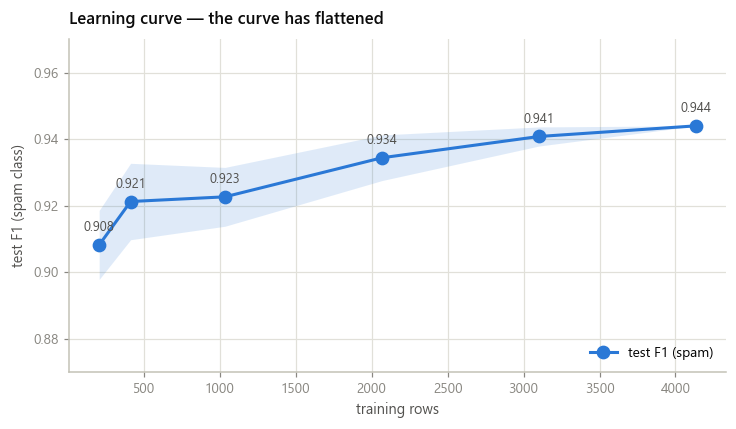

5% -> 100% (206 -> 4,136 rows): +0.0358 F1
doubling the data (50% -> 100%):                +0.0096 F1


In [6]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(curve["rows"], curve["f1_mean"], marker="o", color=SERIES[0], label="test F1 (spam)")
ax.fill_between(curve["rows"],
                curve["f1_mean"] - curve["f1_std"],
                curve["f1_mean"] + curve["f1_std"],
                color=SERIES[0], alpha=0.15)
for _, r in curve.iterrows():
    ax.annotate(f"{r['f1_mean']:.3f}", (r["rows"], r["f1_mean"]),
                textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=8.5, color=INK_SECONDARY)
ax.set_title("Learning curve — the curve has flattened")
ax.set_xlabel("training rows")
ax.set_ylabel("test F1 (spam class)")
ax.set_ylim(0.87, 0.97)
ax.legend(loc="lower right")
despine(ax)
plt.tight_layout()
plt.show()

first, last = curve.iloc[0], curve.iloc[-1]
half = curve[curve["fraction"] == 0.50].iloc[0]
print(f"5% -> 100% ({first['rows']:,.0f} -> {last['rows']:,.0f} rows): "
      f"{last['f1_mean'] - first['f1_mean']:+.4f} F1")
print(f"doubling the data (50% -> 100%):                {last['f1_mean'] - half['f1_mean']:+.4f} F1")

### 5.2 Would resampling or SMOTE help? — six strategies, one fixed test set

The other objection: the classes are imbalanced, so rebalance them.

**The test set is never resampled.** Resampling is a training-time intervention;
evaluating on an artificially balanced test set reports a number that does not exist in
production. Every row below is scored on the identical, untouched 1,035 messages.

Resampling also happens strictly **inside the training partition**, after the split — the
same principle the preprocessing template enforces. SMOTE applied before splitting would
manufacture synthetic points from test rows and leak them into training.

In [7]:
def evaluate(name, X, y):
    model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X, y)
    pred = model.predict(X_test)
    return {
        "strategy": name,
        "train rows": len(X),
        "train spam %": float(np.mean(y)),
        "precision": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_test, pred, pos_label=1, zero_division=0),
    }

results = [evaluate("none (shipped)", X_train, y_train)]

model_bal = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
).fit(X_train, y_train)
pred_bal = model_bal.predict(X_test)
results.append({
    "strategy": "class_weight=balanced", "train rows": len(X_train),
    "train spam %": float(y_train.mean()),
    "precision": precision_score(y_test, pred_bal, pos_label=1, zero_division=0),
    "recall": recall_score(y_test, pred_bal, pos_label=1, zero_division=0),
    "f1": f1_score(y_test, pred_bal, pos_label=1, zero_division=0),
})

for label, sampler in [
    ("RandomOverSampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("SMOTE (k=5)", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("SMOTE (k=1)", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ("RandomUnderSampler", RandomUnderSampler(random_state=RANDOM_STATE)),
]:
    Xr, yr = sampler.fit_resample(X_train, y_train)
    results.append(evaluate(label, Xr, pd.Series(yr)))

resampling = pd.DataFrame(results)
base_f1 = resampling.iloc[0]["f1"]
resampling["F1 vs shipped"] = resampling["f1"] - base_f1
display(resampling.set_index("strategy").style.format({
    "train rows": "{:,.0f}", "train spam %": "{:.1%}",
    "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}",
    "F1 vs shipped": "{:+.4f}",
}))

,train rows,train spam %,precision,recall,f1,F1 vs shipped
strategy,,,,,,
none (shipped),"4,136",12.6%,0.9916,0.9008,0.9440,+0.0000
class_weight=balanced,"4,136",12.6%,0.9836,0.9160,0.9486,+0.0046
RandomOverSampler,"7,228",50.0%,0.9453,0.9237,0.9344,-0.0096
SMOTE (k=5),"7,228",50.0%,0.9600,0.9160,0.9375,-0.0065
SMOTE (k=1),"7,228",50.0%,0.9528,0.9237,0.9380,-0.0060
RandomUnderSampler,"1,044",50.0%,0.8621,0.9542,0.9058,-0.0382


### 5.3 Is the large corpus usable? — contamination audit

Now the check that decided the question.

`marker_audit` takes a handful of **trivial surface markers** — does the text contain a
digit, an uppercase letter, an exclamation mark — and measures how well each separates
the classes *on its own*. A marker that shouldn't be decisive but is tells you something
is wrong with how the corpus was assembled.

In [8]:
audits = {}
for name, (texts, y, _note) in corpora.items():
    audits[name] = marker_audit(texts, y)

for name, audit in audits.items():
    print("=" * 78)
    print(name)
    print("=" * 78)
    display(audit.set_index("marker").style.format({
        "negative_%": "{:.1%}", "positive_%": "{:.1%}",
        "auc": "{:.3f}", "auc_distance": "{:.3f}",
    }))

SMS Spam (current)


,negative_%,positive_%,auc,exact_zero,auc_distance
marker,,,,,
has a raw digit,15.7%,94.8%,0.896,False,0.396
has '!',11.6%,49.0%,0.687,False,0.187
has a currency symbol,0.4%,34.4%,0.670,False,0.170
has http/www,0.0%,14.3%,0.571,False,0.071
has any uppercase,99.9%,100.0%,0.500,False,0.000
has 'escapenumber',0.0%,0.0%,0.500,False,0.000


Big 300k (ham vs spam)


,negative_%,positive_%,auc,exact_zero,auc_distance
marker,,,,,
has a raw digit,12.4%,93.6%,0.906,False,0.406
has 'escapenumber',75.7%,0.0%,0.122,True,0.378
has http/www,26.2%,51.0%,0.624,False,0.124
has '!',2.1%,0.0%,0.490,True,0.010
has a currency symbol,1.8%,0.0%,0.491,True,0.009
has any uppercase,100.0%,100.0%,0.500,False,0.000


Enron-Spam


,negative_%,positive_%,auc,exact_zero,auc_distance
marker,,,,,
has '!',16.9%,54.6%,0.689,False,0.189
has http/www,7.6%,30.4%,0.614,False,0.114
has a currency symbol,14.1%,28.7%,0.573,False,0.073
has a raw digit,88.1%,78.8%,0.453,False,0.047
has any uppercase,100.0%,99.7%,0.498,False,0.002
has 'escapenumber',0.0%,0.0%,0.500,False,0.000


Phishing emails


,negative_%,positive_%,auc,exact_zero,auc_distance
marker,,,,,
has '!',21.8%,58.1%,0.682,False,0.182
has a currency symbol,14.1%,32.2%,0.590,False,0.090
has a raw digit,87.1%,78.8%,0.458,False,0.042
has http/www,39.6%,34.3%,0.474,False,0.026
has any uppercase,100.0%,99.9%,0.500,False,0.000
has 'escapenumber',0.0%,0.0%,0.500,False,0.000


### The trap I nearly fell into

Look at the `auc` column and a naive rule suggests itself: *"flag any corpus with a
single-marker AUC above ~0.85 as contaminated."*

**That rule fires on the SMS corpus.** `has a raw digit` scores **0.896** there — 94.8%
of spam contains a digit against 15.7% of ham.

And the SMS corpus is fine. Spam has to carry a phone number, a shortcode or a price;
ordinary texting does not. The marker separates the classes because of a **real causal
mechanism in the world**.

So a high single-marker AUC is evidence of *nothing on its own*. It means "this marker
separates the classes", which is precisely what a genuinely strong feature also does.
The threshold approach cannot tell signal from artefact, because both look identical
in that column.

## 6. Evaluation

### 6.1 What actually distinguishes contamination from signal

Two things, neither of them a threshold:

**1. An exact zero.** Real phenomena leak. If a marker appears in 75% of one class and
**exactly 0.00%** of the other, that is not a fact about spam — it is a fact about two
files being preprocessed by two different pipelines. Real distributions do not produce
hard zeros on 40,000 rows.

**2. A causal story you can state out loud.** "Spam contains phone numbers because the
victim has to call them" is a mechanism. "Ham contains the literal token `escapenumber`
and spam never does" is not a mechanism — it is a description of a substitution someone
ran on one source and not the other.

In [9]:
print("markers that are absent from exactly one class AND separate strongly:\n")
for name, audit in audits.items():
    flagged = suspicious_zero_cells(audit)
    if len(flagged):
        print(f"  {name}:")
        for _, r in flagged.iterrows():
            print(f"      '{r['marker']}'  ->  negative {r['negative_%']:.2%}, "
                  f"positive {r['positive_%']:.2%},  AUC {r['auc']:.3f}   *** CONTAMINATED")
    else:
        print(f"  {name}: none")

markers that are absent from exactly one class AND separate strongly:

  SMS Spam (current): none
  Big 300k (ham vs spam):
      'has 'escapenumber''  ->  negative 75.66%, positive 0.00%,  AUC 0.122   *** CONTAMINATED
  Enron-Spam: none
  Phishing emails: none


In [10]:
# The decisive comparison: same marker, same magnitude, opposite meaning.
comparison = []
for name in ["SMS Spam (current)", "Big 300k (ham vs spam)"]:
    if name not in audits:
        continue
    a = audits[name]
    for marker in ["has a raw digit", "has 'escapenumber'"]:
        row = a[a["marker"] == marker]
        if len(row):
            r = row.iloc[0]
            comparison.append({
                "corpus": name, "marker": marker,
                "negative %": r["negative_%"], "positive %": r["positive_%"],
                "AUC": r["auc"], "exact zero": r["exact_zero"],
            })
display(pd.DataFrame(comparison).set_index(["corpus", "marker"]).style.format({
    "negative %": "{:.2%}", "positive %": "{:.2%}", "AUC": "{:.3f}",
}))

There it is. `has a raw digit` scores **0.896 on SMS** and **0.906 on the 300k corpus** —
statistically indistinguishable, and opposite in meaning.

The tie-breaker is the row beneath: on the 300k corpus, `escapenumber` appears in **75.66%
of ham and 0.00% of spam**. The ham came from the Enron corpus with numbers substituted
away; the spam came from elsewhere with its digits intact. So on that corpus the digit
features do not measure spam — **they measure which source file the row came from.**

That is fatal here specifically, because `digit_count`, `digit_ratio` and
`has_long_digit_run` are the top three features in notebook 02, carrying **63% of the
model's importance**. A model trained on that corpus would score beautifully and have
learned the data collection process.

### 6.2 Verdict

In [11]:
verdict = []
for name, (texts, y, note) in corpora.items():
    audit = audits[name]
    dead = int((viability[name] == "dead").sum())
    contaminated = len(suspicious_zero_cells(audit)) > 0
    if contaminated:
        call = "REJECT — label recoverable from an assembly artefact"
    elif dead >= 3:
        call = f"usable, but {dead}/12 features are dead"
    else:
        call = "clean"
    verdict.append({
        "corpus": name, "rows": len(texts), "positive %": y.mean(),
        "dead features": f"{dead}/12",
        "worst marker AUC": audit["auc_distance"].max() + 0.5,
        "verdict": call,
    })
display(pd.DataFrame(verdict).set_index("corpus").style.format({
    "rows": "{:,.0f}", "positive %": "{:.1%}", "worst marker AUC": "{:.3f}",
}))

,rows,positive %,dead features,worst marker AUC,verdict
corpus,,,,,
SMS Spam (current),"5,574",13.4%,0/12,0.896,clean
Big 300k (ham vs spam),"169,798",25.2%,3/12,0.906,REJECT — label recoverable from an assembly artefact
Enron-Spam,"33,716",50.9%,3/12,0.689,"usable, but 3/12 features are dead"
Phishing emails,"18,634",39.2%,0/12,0.682,clean


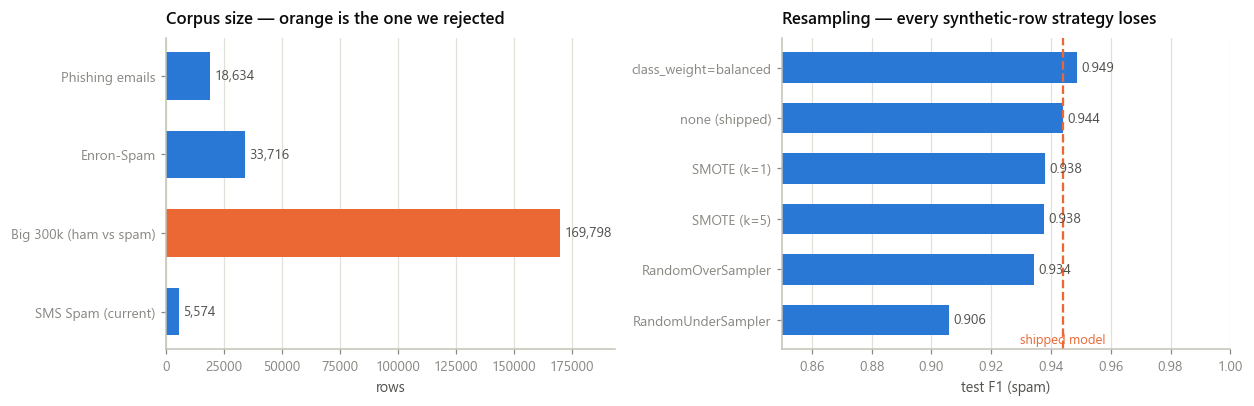

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

v = pd.DataFrame(verdict)
colors = [SERIES[1] if "REJECT" in c else SERIES[0] for c in v["verdict"]]
axes[0].barh(v["corpus"], v["rows"], color=colors, height=0.6)
annotate_bars(axes[0], fmt="{:,.0f}", horizontal=True)
axes[0].set_title("Corpus size — orange is the one we rejected")
axes[0].set_xlabel("rows")
axes[0].grid(axis="y", visible=False)
despine(axes[0])

r = resampling.sort_values("f1")
axes[1].barh(r["strategy"], r["f1"], color=SERIES[0], height=0.6)
axes[1].axvline(base_f1, color=SERIES[1], linestyle="--", linewidth=1.5)
axes[1].annotate("shipped model", (base_f1, -0.45), fontsize=8.5,
                 color=SERIES[1], ha="center")
annotate_bars(axes[1], fmt="{:.3f}", horizontal=True)
axes[1].set_title("Resampling — every synthetic-row strategy loses")
axes[1].set_xlabel("test F1 (spam)")
axes[1].set_xlim(0.85, 1.0)
axes[1].grid(axis="y", visible=False)
despine(axes[1])

plt.tight_layout()
plt.show()

### 6.3 Conclusions

In [13]:
best = resampling.loc[resampling["f1"].idxmax()]
shipped = resampling.iloc[0]
caught_base = int(round(shipped["recall"] * y_test.sum()))
caught_best = int(round(best["recall"] * y_test.sum()))

print("=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)
print(f"1. more data      : doubling the training set buys "
      f"{curve.iloc[-1]['f1_mean'] - curve[curve.fraction == 0.5].iloc[0]['f1_mean']:+.4f} F1")
print(f"2. resampling     : best strategy is '{best['strategy']}' at F1 {best['f1']:.4f} "
      f"({best['f1'] - shipped['f1']:+.4f})")
print(f"                    in messages: {caught_base} -> {caught_best} spam caught "
      f"out of {int(y_test.sum())}")
print(f"3. bigger corpus  : "
      f"{sum(1 for v in verdict if 'REJECT' in v['verdict'])} of {len(verdict)} candidates rejected "
      f"as contaminated")
print("=" * 80)

AUDIT SUMMARY
1. more data      : doubling the training set buys +0.0096 F1
2. resampling     : best strategy is 'class_weight=balanced' at F1 0.9486 (+0.0046)
                    in messages: 118 -> 120 spam caught out of 131
3. bigger corpus  : 1 of 4 candidates rejected as contaminated


**1. The corpus is not too small.** Doubling the training data moves spam F1 by about one
point. The curve is flat because the ceiling is the *feature set* — twelve numbers
describing message shape, with no access to word identity — and not the row count. That
is the same ceiling written up in notebook 02's LIMITATIONS, arriving here from a
different direction.

**2. Resampling does not help, and SMOTE slightly hurts.** Every oversampling strategy
trades away more precision than it buys in recall. `class_weight="balanced"` is the only
one that improves F1, by +0.005 — which in real terms is **two more spam messages caught
and one more legitimate message misfiled**. That is a policy choice about the relative
cost of the two errors, not a modelling improvement, and notebook 02 presents the whole
precision–recall frontier rather than picking one point on it.

Undersampling is the worst option by a distance: it throws away 3,092 real rows to fix a
ratio, and loses 0.038 F1 doing it.

**3. The largest available corpus would have produced a fake result.** 170,000 rows,
better class balance, and a label partly recoverable from a preprocessing artefact. The
three most important features in this project would have been measuring which source
file each row came from.

**4. The check that matters is not a threshold.** A single-marker AUC of ~0.90 appears in
both the clean corpus and the contaminated one. What separates them is an exact-zero cell
and whether a causal mechanism can be stated. This is the same lesson as the dummy-variable
trap in notebook 03 and the leakage guards in the preprocessing template: **the dangerous
failures are the ones that return a plausible number instead of an error.**

### What was actually changed as a result

Nothing. The SMS corpus stays, the twelve features stay, `class_weight` stays at `None`.

An audit that changes nothing is not a wasted audit — the alternative was switching to a
corpus that would have inflated every number in this repository, and "we measured and the
current choice held up" is a different statement from "we never checked."